Train data shape: (5000, 500, 3)
Test data shape: (100, 750, 3)


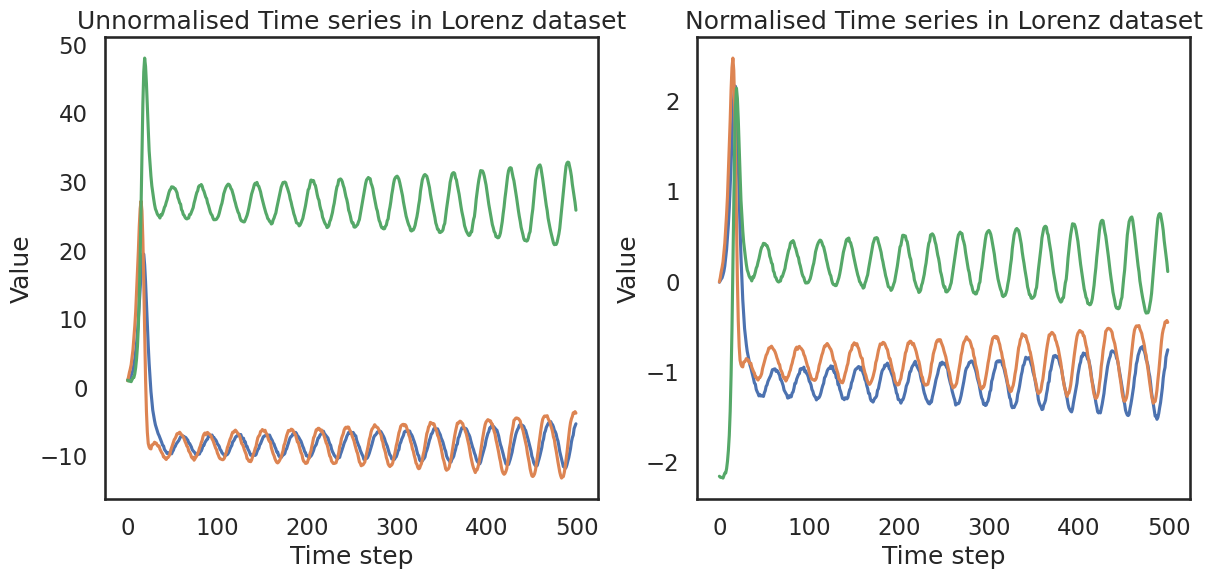

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import torch
from jax.tree_util import tree_map
from torch.utils import data
import math
## Set seeds

sns.set(style="white", context="talk")

# --- 1. Data Loading (Same as before) ---
train_data = np.load('lorenz/train.npy')
test_data = np.load('lorenz/test.npy')

train_mean = np.mean(train_data, axis=(0,1), keepdims=True)
train_std = np.std(train_data, axis=(0,1), keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(train_data[0], label='Sample 0')
ax1.set_title("Unnormalised Time series in Lorenz dataset")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Value")

train_data = (train_data - train_mean) / train_std
test_data = (test_data - train_mean) / train_std

print(f"Train data shape: {train_data.shape}")  # (num_trajectories, num_timepoints, state_dimension)
print(f"Test data shape: {test_data.shape}")

## Plot normalisied and unnormalised data on two axies
ax2.plot(train_data[0], label='Sample 0')
ax2.set_title("Normalised Time series in Lorenz dataset")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Value")

class LorenzDataset(data.Dataset):
    def __init__(self, data):
        self.data = torch.from_numpy(data).float()
    def __len__(self):
        return self.data.shape[0]
    def __getitem__(self, idx):
        rdm_start = np.random.randint(0, self.data.shape[1] - CONFIG["train_seq_len"])
        # return self.data[idx]
        return self.data[idx, rdm_start : rdm_start + CONFIG["train_seq_len"], :]

def numpy_collate(batch):
  return tree_map(np.asarray, data.default_collate(batch))

CONFIG = {
    "seed": 42,
    "n_epochs": 80*10,
    "print_every": 5*10,
    "batch_size": 128*4,
    "train_seq_len": 20,
    "history_len": 15,
    # "future_len": 50,
    "ar_train_mode": True,  # Whether to use AR mode during training
    "node_refinement": True,  # Whether to use refinement head
    "n_refine_steps": 10,
}

np.random.seed(CONFIG["seed"])
batch_size = CONFIG["batch_size"]
history_len = CONFIG["history_len"]
# future_len = CONFIG["future_len"]
ar_train_mode = CONFIG["ar_train_mode"]
node_refinement = CONFIG["node_refinement"]

train_dataset = LorenzDataset(train_data)
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=numpy_collate, num_workers=24)

In [ ]:
# --- 2. Decoder-Only Components ---

class PositionalEncoding(eqx.Module):
    embedding: jax.Array
    def __init__(self, d_model: int, max_len: int = 500):
        pe = jnp.zeros((max_len, d_model))
        position = jnp.arange(0, max_len, dtype=jnp.float32)[:, jnp.newaxis]
        div_term = jnp.exp(jnp.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = pe.at[:, 0::2].set(jnp.sin(position * div_term))
        pe = pe.at[:, 1::2].set(jnp.cos(position * div_term))
        self.embedding = pe
    def __call__(self, x, start_idx=0):
        # We need start_idx because in AR inference we might embed 
        # just the newly added tokens, so we need their correct absolute position.
        return x + self.embedding[start_idx : start_idx + x.shape[0], :]

class TransformerBlock(eqx.Module):
    # Standard Block: Self-Attention -> MLP
    attention: eqx.nn.MultiheadAttention
    norm1: eqx.nn.LayerNorm
    mlp: eqx.nn.MLP
    norm2: eqx.nn.LayerNorm
    
    def __init__(self, d_model, n_heads, d_ff, dropout, key):
        k1, k2 = jax.random.split(key)
        self.attention = eqx.nn.MultiheadAttention(
            num_heads=n_heads, query_size=d_model, dropout_p=dropout, key=k1
        )
        self.norm1 = eqx.nn.LayerNorm(d_model)
        self.mlp = eqx.nn.MLP(
            in_size=d_model, out_size=d_model, width_size=d_ff, depth=1, activation=jax.nn.gelu, key=k2
        )
        self.norm2 = eqx.nn.LayerNorm(d_model)

    def __call__(self, x, mask=None, key=None):
        # Standard Pre-Norm or Post-Norm. Using Post-Norm here to match prev code style
        attn_out = self.attention(x, x, x, mask=mask, key=key)
        x = jax.vmap(self.norm1)(x + attn_out)
        mlp_out = jax.vmap(self.mlp)(x)
        x = jax.vmap(self.norm2)(x + mlp_out)
        return x

class DecoderOnlyTransformer(eqx.Module):
    embedding: eqx.nn.Linear
    pos_encoder: PositionalEncoding
    blocks: list
    
    # Heads
    output_projection: eqx.nn.Linear
    refinement_mlp: eqx.nn.MLP
    
    d_model: int = eqx.field(static=True)
    n_substeps: int = eqx.field(static=True)

    def __init__(self, input_dim, d_model, n_heads, n_layers, d_ff, n_substeps, max_len, key):
        self.d_model = d_model
        self.n_substeps = n_substeps
        
        keys = jax.random.split(key, 5)
        
        self.embedding = eqx.nn.Linear(input_dim, d_model, key=keys[0])
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
        
        # Single Stack of Blocks
        self.blocks = [
            TransformerBlock(d_model, n_heads, d_ff, dropout=0.0, key=k)
            for k in jax.random.split(keys[1], n_layers)
        ]
        
        # Standard Head
        self.output_projection = eqx.nn.Linear(d_model, input_dim, key=keys[2])
        zeros_w = jnp.zeros_like(self.output_projection.weight)
        zeros_b = jnp.zeros_like(self.output_projection.bias)
        self.output_projection = eqx.tree_at(
            lambda l: (l.weight, l.bias), self.output_projection, (zeros_w, zeros_b)
        )

        # Refinement Head
        self.refinement_mlp = eqx.nn.MLP(
            in_size=d_model * 2,
            out_size=input_dim,
            width_size=d_ff,
            depth=1,
            activation=jax.nn.gelu,
            key=keys[3]
        )
        # Zero Init
        zeros_w_ref = jnp.zeros_like(self.refinement_mlp.layers[-1].weight)
        zeros_b_ref = jnp.zeros_like(self.refinement_mlp.layers[-1].bias)
        self.refinement_mlp = eqx.tree_at(
            lambda m: (m.layers[-1].weight, m.layers[-1].bias),
            self.refinement_mlp,
            (zeros_w_ref, zeros_b_ref)
        )

    def make_causal_mask(self, seq_len):
        # Eqx mask: True = ignore (mask out)
        # We want to ignore indices where col > row (future looking at past is ok, past looking at future is not)
        idx = jnp.arange(seq_len)
        mask = idx[:, None] < idx[None, :] 
        return mask

    def make_nsteps_causal_mask(self, seq_len, n_steps):
        # Eqx mask: True = ignore (mask out)
        idx = jnp.arange(seq_len)
        mask = idx[:, None] < (idx[None, :] - n_steps + 1)
        return mask

    def refine_step(self, start_val, context_h):
        # x_t -> x_{t+1}
        def loop_fn(i, curr_val):
            w_emb = self.embedding(curr_val) * jnp.sqrt(self.d_model)
            combined = jnp.concatenate([w_emb, context_h])
            delta = self.refinement_mlp(combined)
            return curr_val + delta
        return jax.lax.fori_loop(0, self.n_substeps, loop_fn, start_val)

    def __call__(self, history, future=None, steps=None, ar_mode=False, refinement=False, key=None):
        """
        Decoder-Only Logic:
        - ar_mode=False: Concat [History, Future], run full sequence, mask future.
        - ar_mode=True: Run history, then autoregressively append.
        """
        
        # =========================================================
        # MODE A: TEACHER FORCING (Training)
        # =========================================================
        if not ar_mode:
            assert future is not None
            
            # 1. Concatenate History and Future
            # We want to predict [H_1...H_n, F_0...F_m]
            # Input sequence: [H_0...H_{n-1}, H_n(last), F_0...F_{m-1}]
            # Actually, simplest is:
            # Full sequence S = [History, Future]
            # Input to transformer: S[:-1]
            # Output of transformer at index i predicts S[i+1]
            
            full_seq = jnp.concatenate([history, future], axis=0)
            input_seq = full_seq[:-1] # Shifted by 1 implicitly for next-token pred
            
            # 2. Run Transformer
            x = jax.vmap(self.embedding)(input_seq) * jnp.sqrt(self.d_model)
            x = self.pos_encoder(x)
            mask = self.make_causal_mask(x.shape[0])
            # mask = self.make_nsteps_causal_mask(x.shape[0], n_steps=1)
            
            for block in self.blocks:
                x = block(x, mask=mask, key=key)
            
            # x contains contexts [z_0, ... z_{N-1}]
            # z_i is used to predict full_seq[i+1]
            
            # 3. Prediction
            if not refinement:
                deltas = jax.vmap(self.output_projection)(x)
                predictions_next = input_seq + deltas
            else:
                # Parallel Refinement
                # We refine input_seq[i] to get full_seq[i+1] using context x[i]
                predictions_next = jax.vmap(self.refine_step)(input_seq, x)
                
            # We now have predictions for [H_1 ... H_n, F_0 ... F_m]
            # We strictly care about the predictions for F_0 ... F_m
            
            history_len_minus_1 = history.shape[0] - 1
            # The future predictions start at index (history_len - 1)
            # Because input_seq[history_len-1] is the *last history point*.
            # Its prediction corresponds to the first future point.
            
            future_predictions = predictions_next[history_len_minus_1:]
            
            return future_predictions

        # =========================================================
        # MODE B: AUTOREGRESSIVE (Inference)
        # =========================================================
        else:
            if steps is None: steps = future.shape[0] if future is not None else 10
            
            # 1. Process History First
            # We need to run the history to build up the causal context.
            # Unlike Encoder-Decoder where history is "encoded" once,
            # here history is just the prefix of the sequence.
            
            # Optimization: We can run the history part in parallel once to get the cache (if using KV cache).
            # Without KV cache (simplest JAX implementation), we just maintain the full growing sequence
            # or use a scan over the future window re-running the function.
            
            # For this demo, let's stick to the "Buffer" approach from previous code, 
            # but adapted for Decoder-only.
            
            # Total length needed = history + steps
            total_len = history.shape[0] + steps
            
            # Initialize buffer with history
            # Shape: (total_len, input_dim)
            buffer = jnp.zeros((total_len, history.shape[1]))
            buffer = buffer.at[:history.shape[0]].set(history)
            
            # We need a start index for the loop
            start_gen_idx = history.shape[0]
            
            def scan_fn(current_buffer, step_idx):
                # step_idx runs from 0 to steps-1
                # current 'write' head is at start_gen_idx + step_idx
                
                # Current sequence length we care about:
                # We need to run the transformer up to (start_gen_idx + step_idx)
                # to get the context for the *next* token.
                
                # To keep shapes static for JIT, we run on the WHOLE buffer 
                # but apply a mask that hides the "future" zeros we haven't filled yet.
                
                # 1. Embed & Pos Encode
                x = jax.vmap(self.embedding)(current_buffer) * jnp.sqrt(self.d_model)
                x = self.pos_encoder(x)
                
                # 2. Masking
                # Standard causal mask
                causal_mask = self.make_causal_mask(total_len)
                
                # Dynamic Mask: Hide everything after the current known point
                # The current known point is 'curr_ptr - 1' (the input)
                curr_ptr = start_gen_idx + step_idx
                
                # We combine causal mask with a "valid length" mask?
                # Actually, standard causal mask is enough IF we don't care about the zeros impacting normalization stats.
                # But LayerNorm stats *will* be affected by trailing zeros.
                # Correct approach in JAX scan with fixed shapes is masking the attention scores.
                # But simpler here: standard causal mask handles it because 
                # position 'curr_ptr' cannot attend to 'curr_ptr+1' (which are zeros).
                # The only issue is that position 'curr_ptr' attends to itself? No, standard causal is triangular.
                # So the embedding at 'curr_ptr-1' (last real data) only attends to history. Correct.
                
                for block in self.blocks:
                    x = block(x, mask=causal_mask, key=key)
                
                # 3. Get Context for the *next* step
                # The input at (curr_ptr - 1) generates context for (curr_ptr)
                context_h = x[curr_ptr - 1]
                input_val = current_buffer[curr_ptr - 1]
                
                # 4. Predict
                if not refinement:
                    delta = self.output_projection(context_h)
                    next_val = input_val + delta
                else:
                    next_val = self.refine_step(input_val, context_h)
                
                # 5. Update Buffer
                new_buffer = current_buffer.at[curr_ptr].set(next_val)
                
                return new_buffer, next_val

            indices = jnp.arange(steps)
            final_buffer, predictions = jax.lax.scan(scan_fn, buffer, indices)
            
            return predictions

In [ ]:
# --- 3. Training Setup ---

key = jax.random.PRNGKey(CONFIG["seed"])
model = DecoderOnlyTransformer(
    input_dim=3,
    d_model=128,
    n_heads=4,
    n_layers=3,
    d_ff=128,
    n_substeps=CONFIG["n_refine_steps"],
    # max_len=128, # Needs to fit history + future
    max_len=max(train_data.shape[1], test_data.shape[1]),
    key=key
)

optimizer = optax.adamw(learning_rate=3e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

@eqx.filter_jit
def train_step_batch(model, batch_traj, opt_state, key):
    # ## Cut the trajectory to a random starting point
    # traj_start = jax.random.randint(key, (), minval=0, maxval=63-history_len)
    # batch_traj = batch_traj[:, traj_start:, :]

    # batch_traj: (B, total_len, D)
    future_len = batch_traj.shape[1] - history_len
    batch_hist = batch_traj[:, :history_len]
    batch_fut = batch_traj[:, history_len : history_len+future_len]
    
    def loss_fn(model, h, f, k):
        # Teacher Forcing + Refinement
        preds = model(h, future=f, ar_mode=ar_train_mode, refinement=node_refinement, key=k)
        # return jnp.mean((preds - f) ** 2)

        indices = jax.random.choice(k, future_len, shape=(5,), replace=False)
        selected_preds = preds[indices]
        selected_futs = f[indices]
        return jnp.mean((selected_preds - selected_futs) ** 2)
    
    keys = jax.random.split(key, batch_traj.shape[0])
    loss_val, grads = eqx.filter_value_and_grad(
        lambda m: jnp.mean(jax.vmap(loss_fn, in_axes=(None, 0, 0, 0))(m, batch_hist, batch_fut, keys))
    )(model)
    
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_val

Starting Decoder-Only training...


/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely

Epoch 50, Loss: 0.000315
Epoch 100, Loss: 0.000253
Epoch 150, Loss: 0.000220
Epoch 200, Loss: 0.000288
Epoch 250, Loss: 0.000353
Epoch 300, Loss: 0.000223
Epoch 350, Loss: 0.000235
Epoch 400, Loss: 0.000301
Epoch 450, Loss: 0.000324
Epoch 500, Loss: 0.000249
Epoch 550, Loss: 0.000379
Epoch 600, Loss: 0.000241
Epoch 650, Loss: 0.000269
Epoch 700, Loss: 0.000236
Epoch 750, Loss: 0.000252
Epoch 800, Loss: 0.000217


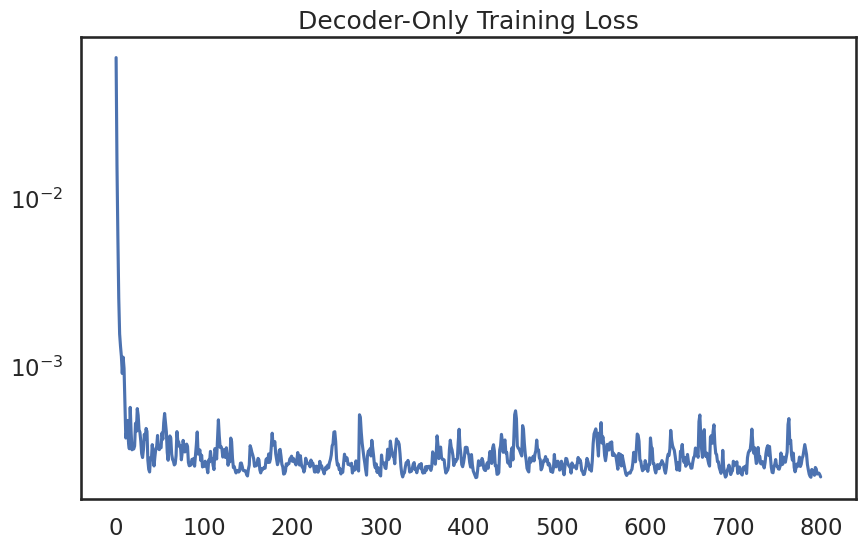

In [ ]:
# --- 4. Training Loop ---
losses = []
print("Starting Decoder-Only training...")

for epoch in range(CONFIG["n_epochs"]):
    batch_losses = []
    key, subkey = jax.random.split(key)
    for batch in train_loader:
        batch = jnp.array(batch)
        ## Pick an integer between 0 and full_len-history_len
        key, subkey = jax.random.split(key)

        model, opt_state, loss = train_step_batch(model, batch, opt_state, subkey)
        batch_losses.append(loss)
    
    avg_loss = np.mean(batch_losses)
    losses.append(avg_loss)
    if (epoch+1) % CONFIG["print_every"] == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.yscale('log')
plt.title("Decoder-Only Training Loss")
plt.show()

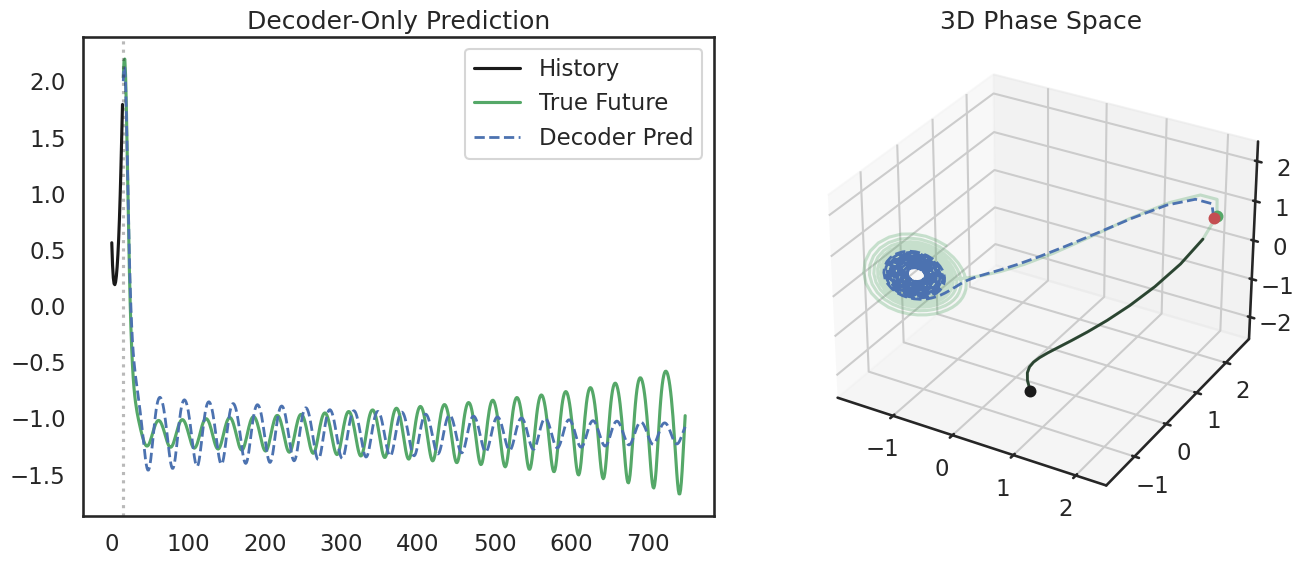

In [ ]:
# --- 5. Visualization (AR Inference) ---

idx = np.random.randint(0, test_data.shape[0])
sample_traj = jnp.array(test_data[idx])
hist = sample_traj[:history_len]
future_len = sample_traj.shape[0] - history_len
# future_len = 24
true_fut = sample_traj[history_len : history_len+future_len]

# AR Inference
pred_fut = model(hist, steps=future_len, ar_mode=True, refinement=node_refinement, key=key)

fig = plt.figure(figsize=(14, 6))
# 1D
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(range(history_len), hist[:, 0], 'k-', label='History', alpha=1)
ax1.plot(range(history_len, history_len+future_len), true_fut[:, 0], 'g-', label='True Future')
ax1.plot(range(history_len, history_len+future_len), pred_fut[:, 0], 'b--', label='Decoder Pred', linewidth=2)
ax1.axvline(history_len, color='k', linestyle=':', alpha=0.3)
ax1.set_title("Decoder-Only Prediction")
ax1.legend()

# 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(hist[:, 0], hist[:, 1], hist[:, 2], 'k-', linewidth=2, label="History")
ax2.plot(sample_traj[:, 0], sample_traj[:, 1], sample_traj[:, 2], 'g', alpha=0.3, label="True")
ax2.plot(pred_fut[:, 0], pred_fut[:, 1], pred_fut[:, 2], 'b--', linewidth=2, label="Pred")

## Plot a dot at the sample and pred starts
ax2.scatter(hist[0, 0], hist[0, 1], hist[0, 2], color='k', s=50, label="History Start")
ax2.scatter(true_fut[0, 0], true_fut[0, 1], true_fut[0, 2], color='g', s=50, label="True Start")
ax2.scatter(pred_fut[0, 0], pred_fut[0, 1], pred_fut[0, 2], color='r', s=50, label="Pred Start")


ax2.set_title("3D Phase Space")
# ax2.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import wasserstein_distance
from sklearn.neighbors import NearestNeighbors

def compute_metrics(model, test_data, history_len, key, refinement=True):
    """
    Computes MSE, MAE, Wasserstein, MMD, and Fractal Dimension.
    
    Args:
        model: The trained JAX model.
        test_data: Shape (num_samples, total_seq_len, input_dim)
        history_len: Length of the input history.
        key: JAX PRNGKey.
        refinement: Boolean flag to use refinement MLP in the model.
        
    Returns:
        Tuple of scalar metrics (avg_mse, avg_mae, avg_wasserstein, avg_mmd, avg_fd)
    """
    
    # 1. Prepare Data
    # test_data shape: (batch, time, dim)
    batch_size, total_len, dim = test_data.shape
    future_len = total_len - history_len
    
    # Split into history (inputs) and true futures (targets)
    hist = jnp.array(test_data[:, :history_len])
    true_fut = jnp.array(test_data[:, history_len:])

    # 2. Batched Inference (GPU/TPU)
    # We define a single inference function and vmap it over the batch
    def predict_single(h, k):
        return model(h, steps=future_len, ar_mode=True, refinement=refinement, key=k)

    # Split keys for the batch
    keys = jax.random.split(key, batch_size)
    
    # Run inference on the whole batch at once
    # pred_fut shape: (batch, future_len, dim)
    pred_fut = eqx.filter_vmap(predict_single)(hist, keys)

    # 3. Compute Vectorized Metrics (JAX)
    mse = jnp.mean((pred_fut - true_fut) ** 2)
    mae = jnp.mean(jnp.abs(pred_fut - true_fut))

    # 4. Compute Complex Metrics (CPU)
    # We convert to numpy to use Scipy and Sklearn, which are not JAX-compatible
    pred_fut_np = np.array(pred_fut)
    true_fut_np = np.array(true_fut)
    
    wasserstein_list = []
    mmd_list = []
    fractal_dim_list = []

    # --- Helper: MMD RBF Kernel ---
    def rbf_kernel_mmd(X, Y, gamma=1.0):
        # Expects X, Y to be (n_samples, 1) for per-dimension calc
        XX = np.mean(np.exp(-gamma * (X - X.T)**2))
        YY = np.mean(np.exp(-gamma * (Y - Y.T)**2))
        XY = np.mean(np.exp(-gamma * (X - Y.T)**2))
        return XX + YY - 2 * XY

    # --- Helper: Fractal Dimension ---
    def fractal_dimension(X, max_dim=10, num_scales=10):
        # X shape: (time, dim)
        if X.shape[0] < max_dim + 1: return 0.0 # Safety check
        nbrs = NearestNeighbors(n_neighbors=max_dim + 1).fit(X)
        distances, _ = nbrs.kneighbors(X)
        
        # Log-log slope estimation
        radii = np.logspace(-2, 1, num_scales)
        counts = []
        for r in radii:
            # Fraction of neighbors within radius r
            count = np.mean(np.sum(distances[:, 1:] < r, axis=1))
            counts.append(count)
        
        counts = np.array(counts)
        # Handle zeros before log
        valid = counts > 0
        if np.sum(valid) < 2: return 0.0
        
        coeffs = np.polyfit(np.log(radii[valid]), np.log(counts[valid]), 1)
        return coeffs[0]

    # Loop over batch on CPU (fast enough for metrics)
    for i in range(batch_size):
        p_traj = pred_fut_np[i] # (time, dim)
        t_traj = true_fut_np[i]
        
        # A. Wasserstein (Per dimension average)
        # Compares the marginal distribution of values in the trajectory
        w_dists = [wasserstein_distance(p_traj[:, d], t_traj[:, d]) for d in range(dim)]
        wasserstein_list.append(np.mean(w_dists))
        
        # B. MMD (Per dimension average)
        m_dists = [rbf_kernel_mmd(p_traj[:, d:d+1], t_traj[:, d:d+1]) for d in range(dim)]
        mmd_list.append(np.mean(m_dists))
        
        # C. Fractal Dimension (On full 3D trajectory)
        fd = fractal_dimension(p_traj)
        fractal_dim_list.append(fd)

    return (
        float(mse), 
        float(mae), 
        np.mean(wasserstein_list), 
        np.mean(mmd_list), 
        np.mean(fractal_dim_list)
    )

test_mse, test_mae, test_wasserstein, test_mmd, test_fd = compute_metrics(model, test_data, history_len, key)
print(f"Test MSE: {test_mse:.6f}, Test MAE: {test_mae:.6f}")
print(f"Test Wasserstein⬇️: {test_wasserstein:.3f}, Test MMD⬇️: {test_mmd:.3f}, Test Fractal Dimension (≅2.06): {test_fd:.3f}")

Test MSE: 0.399978, Test MAE: 0.416451
Test Wasserstein⬇️: 0.288, Test MMD⬇️: 0.094, Test Fractal Dimension (≅2.06): 0.399


Train data shape: (5000, 500, 3)
Test data shape: (100, 750, 3)


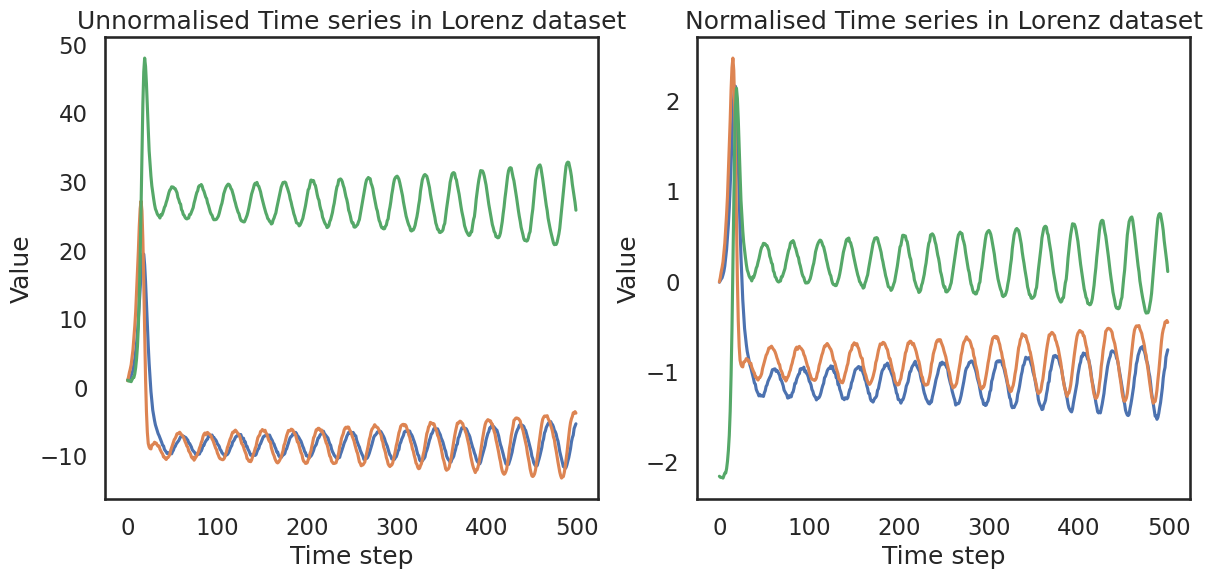

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import torch
from jax.tree_util import tree_map
from torch.utils import data
import math
## Set seeds

sns.set(style="white", context="talk")

# --- 1. Data Loading (Same as before) ---
train_data = np.load('lorenz/train.npy')
test_data = np.load('lorenz/test.npy')

train_mean = np.mean(train_data, axis=(0,1), keepdims=True)
train_std = np.std(train_data, axis=(0,1), keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(train_data[0], label='Sample 0')
ax1.set_title("Unnormalised Time series in Lorenz dataset")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Value")

train_data = (train_data - train_mean) / train_std
test_data = (test_data - train_mean) / train_std

print(f"Train data shape: {train_data.shape}")  # (num_trajectories, num_timepoints, state_dimension)
print(f"Test data shape: {test_data.shape}")

## Plot normalisied and unnormalised data on two axies
ax2.plot(train_data[0], label='Sample 0')
ax2.set_title("Normalised Time series in Lorenz dataset")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Value")

class LorenzDataset(data.Dataset):
    def __init__(self, data):
        self.data = torch.from_numpy(data).float()
    def __len__(self):
        return self.data.shape[0]
    def __getitem__(self, idx):
        rdm_start = np.random.randint(0, self.data.shape[1] - CONFIG["train_seq_len"])
        # return self.data[idx]
        return self.data[idx, rdm_start : rdm_start + CONFIG["train_seq_len"], :]

def numpy_collate(batch):
  return tree_map(np.asarray, data.default_collate(batch))

CONFIG = {
    "seed": 42,
    "n_epochs": 80*10,
    "print_every": 5*10,
    "batch_size": 128*4,
    "train_seq_len": 20,
    "history_len": 15,
    # "future_len": 50,
    "ar_train_mode": True,  # Whether to use AR mode during training
    "node_refinement": False,  # Whether to use refinement head
    "n_refine_steps": 10,
}

np.random.seed(CONFIG["seed"])
batch_size = CONFIG["batch_size"]
history_len = CONFIG["history_len"]
# future_len = CONFIG["future_len"]
ar_train_mode = CONFIG["ar_train_mode"]
node_refinement = CONFIG["node_refinement"]

train_dataset = LorenzDataset(train_data)
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=numpy_collate, num_workers=24)

In [ ]:
# --- 2. Decoder-Only Components ---

class PositionalEncoding(eqx.Module):
    embedding: jax.Array
    def __init__(self, d_model: int, max_len: int = 500):
        pe = jnp.zeros((max_len, d_model))
        position = jnp.arange(0, max_len, dtype=jnp.float32)[:, jnp.newaxis]
        div_term = jnp.exp(jnp.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = pe.at[:, 0::2].set(jnp.sin(position * div_term))
        pe = pe.at[:, 1::2].set(jnp.cos(position * div_term))
        self.embedding = pe
    def __call__(self, x, start_idx=0):
        # We need start_idx because in AR inference we might embed 
        # just the newly added tokens, so we need their correct absolute position.
        return x + self.embedding[start_idx : start_idx + x.shape[0], :]

class TransformerBlock(eqx.Module):
    # Standard Block: Self-Attention -> MLP
    attention: eqx.nn.MultiheadAttention
    norm1: eqx.nn.LayerNorm
    mlp: eqx.nn.MLP
    norm2: eqx.nn.LayerNorm
    
    def __init__(self, d_model, n_heads, d_ff, dropout, key):
        k1, k2 = jax.random.split(key)
        self.attention = eqx.nn.MultiheadAttention(
            num_heads=n_heads, query_size=d_model, dropout_p=dropout, key=k1
        )
        self.norm1 = eqx.nn.LayerNorm(d_model)
        self.mlp = eqx.nn.MLP(
            in_size=d_model, out_size=d_model, width_size=d_ff, depth=1, activation=jax.nn.gelu, key=k2
        )
        self.norm2 = eqx.nn.LayerNorm(d_model)

    def __call__(self, x, mask=None, key=None):
        # Standard Pre-Norm or Post-Norm. Using Post-Norm here to match prev code style
        attn_out = self.attention(x, x, x, mask=mask, key=key)
        x = jax.vmap(self.norm1)(x + attn_out)
        mlp_out = jax.vmap(self.mlp)(x)
        x = jax.vmap(self.norm2)(x + mlp_out)
        return x

class DecoderOnlyTransformer(eqx.Module):
    embedding: eqx.nn.Linear
    pos_encoder: PositionalEncoding
    blocks: list
    
    # Heads
    output_projection: eqx.nn.Linear
    refinement_mlp: eqx.nn.MLP
    
    d_model: int = eqx.field(static=True)
    n_substeps: int = eqx.field(static=True)

    def __init__(self, input_dim, d_model, n_heads, n_layers, d_ff, n_substeps, max_len, key):
        self.d_model = d_model
        self.n_substeps = n_substeps
        
        keys = jax.random.split(key, 5)
        
        self.embedding = eqx.nn.Linear(input_dim, d_model, key=keys[0])
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
        
        # Single Stack of Blocks
        self.blocks = [
            TransformerBlock(d_model, n_heads, d_ff, dropout=0.0, key=k)
            for k in jax.random.split(keys[1], n_layers)
        ]
        
        # Standard Head
        self.output_projection = eqx.nn.Linear(d_model, input_dim, key=keys[2])
        zeros_w = jnp.zeros_like(self.output_projection.weight)
        zeros_b = jnp.zeros_like(self.output_projection.bias)
        self.output_projection = eqx.tree_at(
            lambda l: (l.weight, l.bias), self.output_projection, (zeros_w, zeros_b)
        )

        # Refinement Head
        self.refinement_mlp = eqx.nn.MLP(
            in_size=d_model * 2,
            out_size=input_dim,
            width_size=d_ff,
            depth=1,
            activation=jax.nn.gelu,
            key=keys[3]
        )
        # Zero Init
        zeros_w_ref = jnp.zeros_like(self.refinement_mlp.layers[-1].weight)
        zeros_b_ref = jnp.zeros_like(self.refinement_mlp.layers[-1].bias)
        self.refinement_mlp = eqx.tree_at(
            lambda m: (m.layers[-1].weight, m.layers[-1].bias),
            self.refinement_mlp,
            (zeros_w_ref, zeros_b_ref)
        )

    def make_causal_mask(self, seq_len):
        # Eqx mask: True = ignore (mask out)
        # We want to ignore indices where col > row (future looking at past is ok, past looking at future is not)
        idx = jnp.arange(seq_len)
        mask = idx[:, None] < idx[None, :] 
        return mask

    def make_nsteps_causal_mask(self, seq_len, n_steps):
        # Eqx mask: True = ignore (mask out)
        idx = jnp.arange(seq_len)
        mask = idx[:, None] < (idx[None, :] - n_steps + 1)
        return mask

    def refine_step(self, start_val, context_h):
        # x_t -> x_{t+1}
        def loop_fn(i, curr_val):
            w_emb = self.embedding(curr_val) * jnp.sqrt(self.d_model)
            combined = jnp.concatenate([w_emb, context_h])
            delta = self.refinement_mlp(combined)
            return curr_val + delta
        return jax.lax.fori_loop(0, self.n_substeps, loop_fn, start_val)

    def __call__(self, history, future=None, steps=None, ar_mode=False, refinement=False, key=None):
        """
        Decoder-Only Logic:
        - ar_mode=False: Concat [History, Future], run full sequence, mask future.
        - ar_mode=True: Run history, then autoregressively append.
        """
        
        # =========================================================
        # MODE A: TEACHER FORCING (Training)
        # =========================================================
        if not ar_mode:
            assert future is not None
            
            # 1. Concatenate History and Future
            # We want to predict [H_1...H_n, F_0...F_m]
            # Input sequence: [H_0...H_{n-1}, H_n(last), F_0...F_{m-1}]
            # Actually, simplest is:
            # Full sequence S = [History, Future]
            # Input to transformer: S[:-1]
            # Output of transformer at index i predicts S[i+1]
            
            full_seq = jnp.concatenate([history, future], axis=0)
            input_seq = full_seq[:-1] # Shifted by 1 implicitly for next-token pred
            
            # 2. Run Transformer
            x = jax.vmap(self.embedding)(input_seq) * jnp.sqrt(self.d_model)
            x = self.pos_encoder(x)
            mask = self.make_causal_mask(x.shape[0])
            # mask = self.make_nsteps_causal_mask(x.shape[0], n_steps=1)
            
            for block in self.blocks:
                x = block(x, mask=mask, key=key)
            
            # x contains contexts [z_0, ... z_{N-1}]
            # z_i is used to predict full_seq[i+1]
            
            # 3. Prediction
            if not refinement:
                deltas = jax.vmap(self.output_projection)(x)
                predictions_next = input_seq + deltas
            else:
                # Parallel Refinement
                # We refine input_seq[i] to get full_seq[i+1] using context x[i]
                predictions_next = jax.vmap(self.refine_step)(input_seq, x)
                
            # We now have predictions for [H_1 ... H_n, F_0 ... F_m]
            # We strictly care about the predictions for F_0 ... F_m
            
            history_len_minus_1 = history.shape[0] - 1
            # The future predictions start at index (history_len - 1)
            # Because input_seq[history_len-1] is the *last history point*.
            # Its prediction corresponds to the first future point.
            
            future_predictions = predictions_next[history_len_minus_1:]
            
            return future_predictions

        # =========================================================
        # MODE B: AUTOREGRESSIVE (Inference)
        # =========================================================
        else:
            if steps is None: steps = future.shape[0] if future is not None else 10
            
            # 1. Process History First
            # We need to run the history to build up the causal context.
            # Unlike Encoder-Decoder where history is "encoded" once,
            # here history is just the prefix of the sequence.
            
            # Optimization: We can run the history part in parallel once to get the cache (if using KV cache).
            # Without KV cache (simplest JAX implementation), we just maintain the full growing sequence
            # or use a scan over the future window re-running the function.
            
            # For this demo, let's stick to the "Buffer" approach from previous code, 
            # but adapted for Decoder-only.
            
            # Total length needed = history + steps
            total_len = history.shape[0] + steps
            
            # Initialize buffer with history
            # Shape: (total_len, input_dim)
            buffer = jnp.zeros((total_len, history.shape[1]))
            buffer = buffer.at[:history.shape[0]].set(history)
            
            # We need a start index for the loop
            start_gen_idx = history.shape[0]
            
            def scan_fn(current_buffer, step_idx):
                # step_idx runs from 0 to steps-1
                # current 'write' head is at start_gen_idx + step_idx
                
                # Current sequence length we care about:
                # We need to run the transformer up to (start_gen_idx + step_idx)
                # to get the context for the *next* token.
                
                # To keep shapes static for JIT, we run on the WHOLE buffer 
                # but apply a mask that hides the "future" zeros we haven't filled yet.
                
                # 1. Embed & Pos Encode
                x = jax.vmap(self.embedding)(current_buffer) * jnp.sqrt(self.d_model)
                x = self.pos_encoder(x)
                
                # 2. Masking
                # Standard causal mask
                causal_mask = self.make_causal_mask(total_len)
                
                # Dynamic Mask: Hide everything after the current known point
                # The current known point is 'curr_ptr - 1' (the input)
                curr_ptr = start_gen_idx + step_idx
                
                # We combine causal mask with a "valid length" mask?
                # Actually, standard causal mask is enough IF we don't care about the zeros impacting normalization stats.
                # But LayerNorm stats *will* be affected by trailing zeros.
                # Correct approach in JAX scan with fixed shapes is masking the attention scores.
                # But simpler here: standard causal mask handles it because 
                # position 'curr_ptr' cannot attend to 'curr_ptr+1' (which are zeros).
                # The only issue is that position 'curr_ptr' attends to itself? No, standard causal is triangular.
                # So the embedding at 'curr_ptr-1' (last real data) only attends to history. Correct.
                
                for block in self.blocks:
                    x = block(x, mask=causal_mask, key=key)
                
                # 3. Get Context for the *next* step
                # The input at (curr_ptr - 1) generates context for (curr_ptr)
                context_h = x[curr_ptr - 1]
                input_val = current_buffer[curr_ptr - 1]
                
                # 4. Predict
                if not refinement:
                    delta = self.output_projection(context_h)
                    next_val = input_val + delta
                else:
                    next_val = self.refine_step(input_val, context_h)
                
                # 5. Update Buffer
                new_buffer = current_buffer.at[curr_ptr].set(next_val)
                
                return new_buffer, next_val

            indices = jnp.arange(steps)
            final_buffer, predictions = jax.lax.scan(scan_fn, buffer, indices)
            
            return predictions

In [ ]:
# --- 3. Training Setup ---

key = jax.random.PRNGKey(CONFIG["seed"])
model = DecoderOnlyTransformer(
    input_dim=3,
    d_model=128,
    n_heads=4,
    n_layers=3,
    d_ff=128,
    n_substeps=CONFIG["n_refine_steps"],
    # max_len=128, # Needs to fit history + future
    max_len=max(train_data.shape[1], test_data.shape[1]),
    key=key
)

optimizer = optax.adamw(learning_rate=3e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

@eqx.filter_jit
def train_step_batch(model, batch_traj, opt_state, key):
    # ## Cut the trajectory to a random starting point
    # traj_start = jax.random.randint(key, (), minval=0, maxval=63-history_len)
    # batch_traj = batch_traj[:, traj_start:, :]

    # batch_traj: (B, total_len, D)
    future_len = batch_traj.shape[1] - history_len
    batch_hist = batch_traj[:, :history_len]
    batch_fut = batch_traj[:, history_len : history_len+future_len]
    
    def loss_fn(model, h, f, k):
        # Teacher Forcing + Refinement
        preds = model(h, future=f, ar_mode=ar_train_mode, refinement=node_refinement, key=k)
        # return jnp.mean((preds - f) ** 2)

        indices = jax.random.choice(k, future_len, shape=(5,), replace=False)
        selected_preds = preds[indices]
        selected_futs = f[indices]
        return jnp.mean((selected_preds - selected_futs) ** 2)
    
    keys = jax.random.split(key, batch_traj.shape[0])
    loss_val, grads = eqx.filter_value_and_grad(
        lambda m: jnp.mean(jax.vmap(loss_fn, in_axes=(None, 0, 0, 0))(m, batch_hist, batch_fut, keys))
    )(model)
    
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_val

Starting Decoder-Only training...


/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/gb21553/miniconda3/envs/jax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely

Epoch 50, Loss: 0.000392
Epoch 100, Loss: 0.000419
Epoch 150, Loss: 0.000477
Epoch 200, Loss: 0.000365
Epoch 250, Loss: 0.000275
Epoch 300, Loss: 0.000282
Epoch 350, Loss: 0.000370
Epoch 400, Loss: 0.000262
Epoch 450, Loss: 0.000238
Epoch 500, Loss: 0.000225
Epoch 550, Loss: 0.000237
Epoch 600, Loss: 0.000211
Epoch 650, Loss: 0.000225
Epoch 700, Loss: 0.000218
Epoch 750, Loss: 0.000210
Epoch 800, Loss: 0.000214


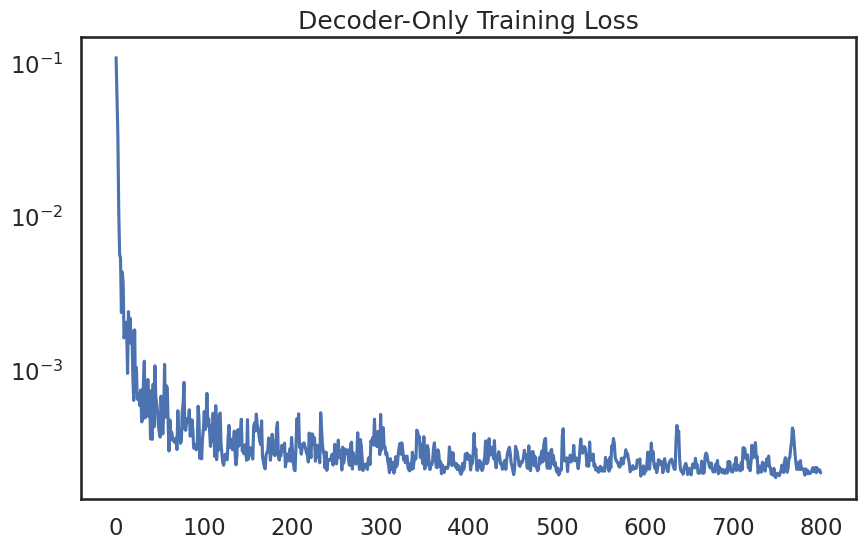

In [ ]:
# --- 4. Training Loop ---
losses = []
print("Starting Decoder-Only training...")

for epoch in range(CONFIG["n_epochs"]):
    batch_losses = []
    key, subkey = jax.random.split(key)
    for batch in train_loader:
        batch = jnp.array(batch)
        ## Pick an integer between 0 and full_len-history_len
        key, subkey = jax.random.split(key)

        model, opt_state, loss = train_step_batch(model, batch, opt_state, subkey)
        batch_losses.append(loss)
    
    avg_loss = np.mean(batch_losses)
    losses.append(avg_loss)
    if (epoch+1) % CONFIG["print_every"] == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.yscale('log')
plt.title("Decoder-Only Training Loss")
plt.show()

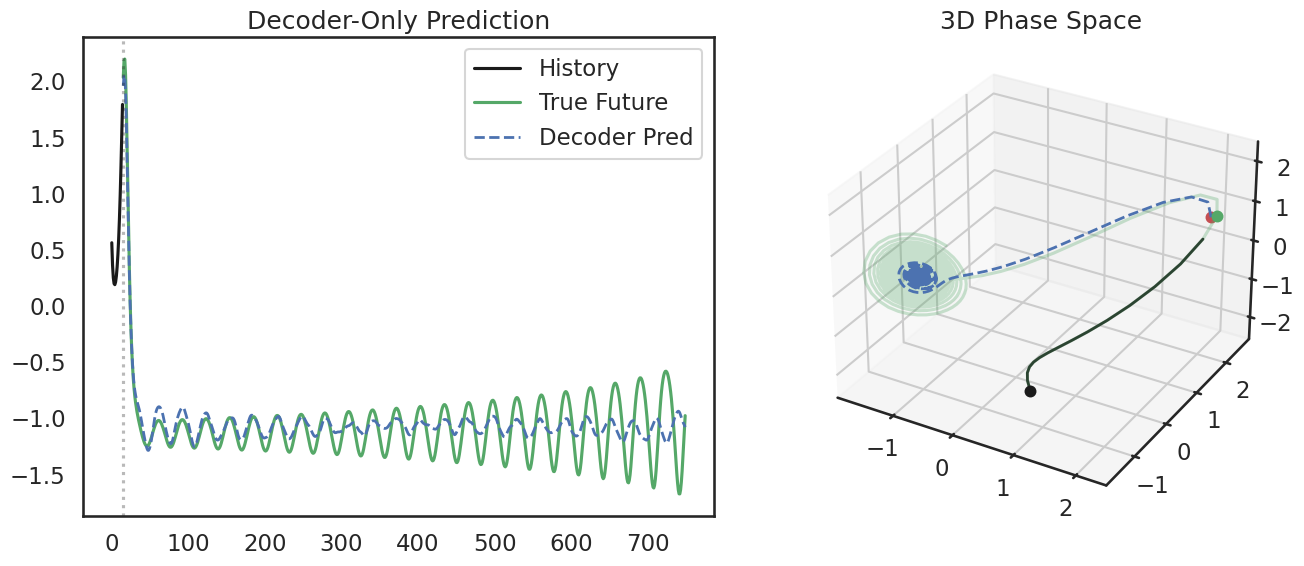

In [ ]:
# --- 5. Visualization (AR Inference) ---

idx = np.random.randint(0, test_data.shape[0])
sample_traj = jnp.array(test_data[idx])
hist = sample_traj[:history_len]
future_len = sample_traj.shape[0] - history_len
# future_len = 24
true_fut = sample_traj[history_len : history_len+future_len]

# AR Inference
pred_fut = model(hist, steps=future_len, ar_mode=True, refinement=node_refinement, key=key)

fig = plt.figure(figsize=(14, 6))
# 1D
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(range(history_len), hist[:, 0], 'k-', label='History', alpha=1)
ax1.plot(range(history_len, history_len+future_len), true_fut[:, 0], 'g-', label='True Future')
ax1.plot(range(history_len, history_len+future_len), pred_fut[:, 0], 'b--', label='Decoder Pred', linewidth=2)
ax1.axvline(history_len, color='k', linestyle=':', alpha=0.3)
ax1.set_title("Decoder-Only Prediction")
ax1.legend()

# 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(hist[:, 0], hist[:, 1], hist[:, 2], 'k-', linewidth=2, label="History")
ax2.plot(sample_traj[:, 0], sample_traj[:, 1], sample_traj[:, 2], 'g', alpha=0.3, label="True")
ax2.plot(pred_fut[:, 0], pred_fut[:, 1], pred_fut[:, 2], 'b--', linewidth=2, label="Pred")

## Plot a dot at the sample and pred starts
ax2.scatter(hist[0, 0], hist[0, 1], hist[0, 2], color='k', s=50, label="History Start")
ax2.scatter(true_fut[0, 0], true_fut[0, 1], true_fut[0, 2], color='g', s=50, label="True Start")
ax2.scatter(pred_fut[0, 0], pred_fut[0, 1], pred_fut[0, 2], color='r', s=50, label="Pred Start")


ax2.set_title("3D Phase Space")
# ax2.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import wasserstein_distance
from sklearn.neighbors import NearestNeighbors

def compute_metrics(model, test_data, history_len, key, refinement=True):
    """
    Computes MSE, MAE, Wasserstein, MMD, and Fractal Dimension.
    
    Args:
        model: The trained JAX model.
        test_data: Shape (num_samples, total_seq_len, input_dim)
        history_len: Length of the input history.
        key: JAX PRNGKey.
        refinement: Boolean flag to use refinement MLP in the model.
        
    Returns:
        Tuple of scalar metrics (avg_mse, avg_mae, avg_wasserstein, avg_mmd, avg_fd)
    """
    
    # 1. Prepare Data
    # test_data shape: (batch, time, dim)
    batch_size, total_len, dim = test_data.shape
    future_len = total_len - history_len
    
    # Split into history (inputs) and true futures (targets)
    hist = jnp.array(test_data[:, :history_len])
    true_fut = jnp.array(test_data[:, history_len:])

    # 2. Batched Inference (GPU/TPU)
    # We define a single inference function and vmap it over the batch
    def predict_single(h, k):
        return model(h, steps=future_len, ar_mode=True, refinement=refinement, key=k)

    # Split keys for the batch
    keys = jax.random.split(key, batch_size)
    
    # Run inference on the whole batch at once
    # pred_fut shape: (batch, future_len, dim)
    pred_fut = eqx.filter_vmap(predict_single)(hist, keys)

    # 3. Compute Vectorized Metrics (JAX)
    mse = jnp.mean((pred_fut - true_fut) ** 2)
    mae = jnp.mean(jnp.abs(pred_fut - true_fut))

    # 4. Compute Complex Metrics (CPU)
    # We convert to numpy to use Scipy and Sklearn, which are not JAX-compatible
    pred_fut_np = np.array(pred_fut)
    true_fut_np = np.array(true_fut)
    
    wasserstein_list = []
    mmd_list = []
    fractal_dim_list = []

    # --- Helper: MMD RBF Kernel ---
    def rbf_kernel_mmd(X, Y, gamma=1.0):
        # Expects X, Y to be (n_samples, 1) for per-dimension calc
        XX = np.mean(np.exp(-gamma * (X - X.T)**2))
        YY = np.mean(np.exp(-gamma * (Y - Y.T)**2))
        XY = np.mean(np.exp(-gamma * (X - Y.T)**2))
        return XX + YY - 2 * XY

    # --- Helper: Fractal Dimension ---
    def fractal_dimension(X, max_dim=10, num_scales=10):
        # X shape: (time, dim)
        if X.shape[0] < max_dim + 1: return 0.0 # Safety check
        nbrs = NearestNeighbors(n_neighbors=max_dim + 1).fit(X)
        distances, _ = nbrs.kneighbors(X)
        
        # Log-log slope estimation
        radii = np.logspace(-2, 1, num_scales)
        counts = []
        for r in radii:
            # Fraction of neighbors within radius r
            count = np.mean(np.sum(distances[:, 1:] < r, axis=1))
            counts.append(count)
        
        counts = np.array(counts)
        # Handle zeros before log
        valid = counts > 0
        if np.sum(valid) < 2: return 0.0
        
        coeffs = np.polyfit(np.log(radii[valid]), np.log(counts[valid]), 1)
        return coeffs[0]

    # Loop over batch on CPU (fast enough for metrics)
    for i in range(batch_size):
        p_traj = pred_fut_np[i] # (time, dim)
        t_traj = true_fut_np[i]
        
        # A. Wasserstein (Per dimension average)
        # Compares the marginal distribution of values in the trajectory
        w_dists = [wasserstein_distance(p_traj[:, d], t_traj[:, d]) for d in range(dim)]
        wasserstein_list.append(np.mean(w_dists))
        
        # B. MMD (Per dimension average)
        m_dists = [rbf_kernel_mmd(p_traj[:, d:d+1], t_traj[:, d:d+1]) for d in range(dim)]
        mmd_list.append(np.mean(m_dists))
        
        # C. Fractal Dimension (On full 3D trajectory)
        fd = fractal_dimension(p_traj)
        fractal_dim_list.append(fd)

    return (
        float(mse), 
        float(mae), 
        np.mean(wasserstein_list), 
        np.mean(mmd_list), 
        np.mean(fractal_dim_list)
    )

test_mse, test_mae, test_wasserstein, test_mmd, test_fd = compute_metrics(model, test_data, history_len, key)
print(f"Test MSE: {test_mse:.6f}, Test MAE: {test_mae:.6f}")
print(f"Test Wasserstein⬇️: {test_wasserstein:.3f}, Test MMD⬇️: {test_mmd:.3f}, Test Fractal Dimension (≅2.06): {test_fd:.3f}")

Test MSE: 4.439339, Test MAE: 1.834526
Test Wasserstein⬇️: 1.835, Test MMD⬇️: 1.279, Test Fractal Dimension (≅2.06): 0.000
